# DSCI-560 Lab 4: Algorithmic Trading Analysis
## Real-Time Stock Price Analysis and Trading Model
### Stock: NVIDIA (NVDA)

#### **Team:** Group 12 | GamerSups

This notebook implements:
1. Data collection using yfinance (with synthetic fallback)
2. Four trading strategies: Moving Average, MACD, RSI, and Hybrid
3. Mock trading environment with commission and slippage
4. Comprehensive performance metrics and visualizations

## 1. Setup and Imports

In [1]:
# Ensure common imports are available for the notebook execution environment
import os
import sys
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
print('Environment imports loaded')

Environment imports loaded


## 2. Configuration Parameters

In [2]:
# Stock and analysis period
STOCK_SYMBOL = 'NVDA'
START_DATE = '2023-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

# Trading parameters
INITIAL_CAPITAL = 100000  # $100,000
COMMISSION_RATE = 0.001   # 0.1% commission
SLIPPAGE_RATE = 0.0005    # 0.05% slippage
RISK_FREE_RATE = 0.02     # 2% annual risk-free rate

print('Trading configuration')
print(f'Stock Symbol: {STOCK_SYMBOL}')
print(f'Analysis Period: {START_DATE} to {END_DATE}')
print(f'Initial Capital: ${INITIAL_CAPITAL:,}')
print(f'Commission Rate: {COMMISSION_RATE*100}%')
print(f'Slippage Rate: {SLIPPAGE_RATE*100}%')

Trading configuration
Stock Symbol: NVDA
Analysis Period: 2023-01-01 to 2026-02-09
Initial Capital: $100,000
Commission Rate: 0.1%
Slippage Rate: 0.05%


## 3. Data Collection

We attempt to download real stock data from Yahoo Finance. If unavailable, we generate realistic synthetic data using geometric Brownian motion.

In [3]:
# Load or generate data
print(f'Downloading {STOCK_SYMBOL} data from Yahoo Finance...')
stock_data = yf.download(STOCK_SYMBOL, start=START_DATE, end=END_DATE, progress=False)
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.get_level_values(0)

stock_data = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
if len(stock_data) > 0:
    print(f'Downloaded {len(stock_data)} days of real {STOCK_SYMBOL} data')
    DATA_SOURCE = 'Yahoo Finance'
else:
    raise ValueError('No data downloaded')

print(f'\nData Source: {DATA_SOURCE}')
print(f'Data Shape: {stock_data.shape}')
print(f'Date Range: {stock_data.index[0].strftime("%Y-%m-%d")} to {stock_data.index[-1].strftime("%Y-%m-%d")}')
stock_data.head()

Downloaded 777 days of real NVDA data

Data Source: Yahoo Finance
Data Shape: (777, 5)
Date Range: 2023-01-03 to 2026-02-06


Price,Open,High,Low,Close,Volume
Date,,,,,
2023-01-03,14.836145,14.981001,14.081900,14.300681,401277000
2023-01-04,14.552433,14.838146,14.226759,14.734250,431324000
2023-01-05,14.476509,14.549436,14.133852,14.250735,389168000
2023-01-06,14.459527,14.994991,14.019967,14.844142,405044000
2023-01-09,15.268716,16.039943,15.125858,15.612371,504231000


## 4. Data Exploration

Price        Open        High         Low       Close        Volume
count  777.000000  777.000000  777.000000  777.000000  7.770000e+02
mean   102.221335  103.869462  100.346180  102.186460  3.512683e+08
std     55.270256   55.925137   54.360664   55.127703  1.767749e+08
min     14.459527   14.549436   14.019967   14.250735  6.552850e+07
25%     46.047299   46.828797   45.128886   45.943577  2.070141e+08
50%    110.949862  113.599382  107.374033  110.539764  3.257210e+08
75%    141.951392  143.463972  138.852443  141.194366  4.494050e+08
max    208.068415  212.178195  205.548551  207.028473  1.543911e+09


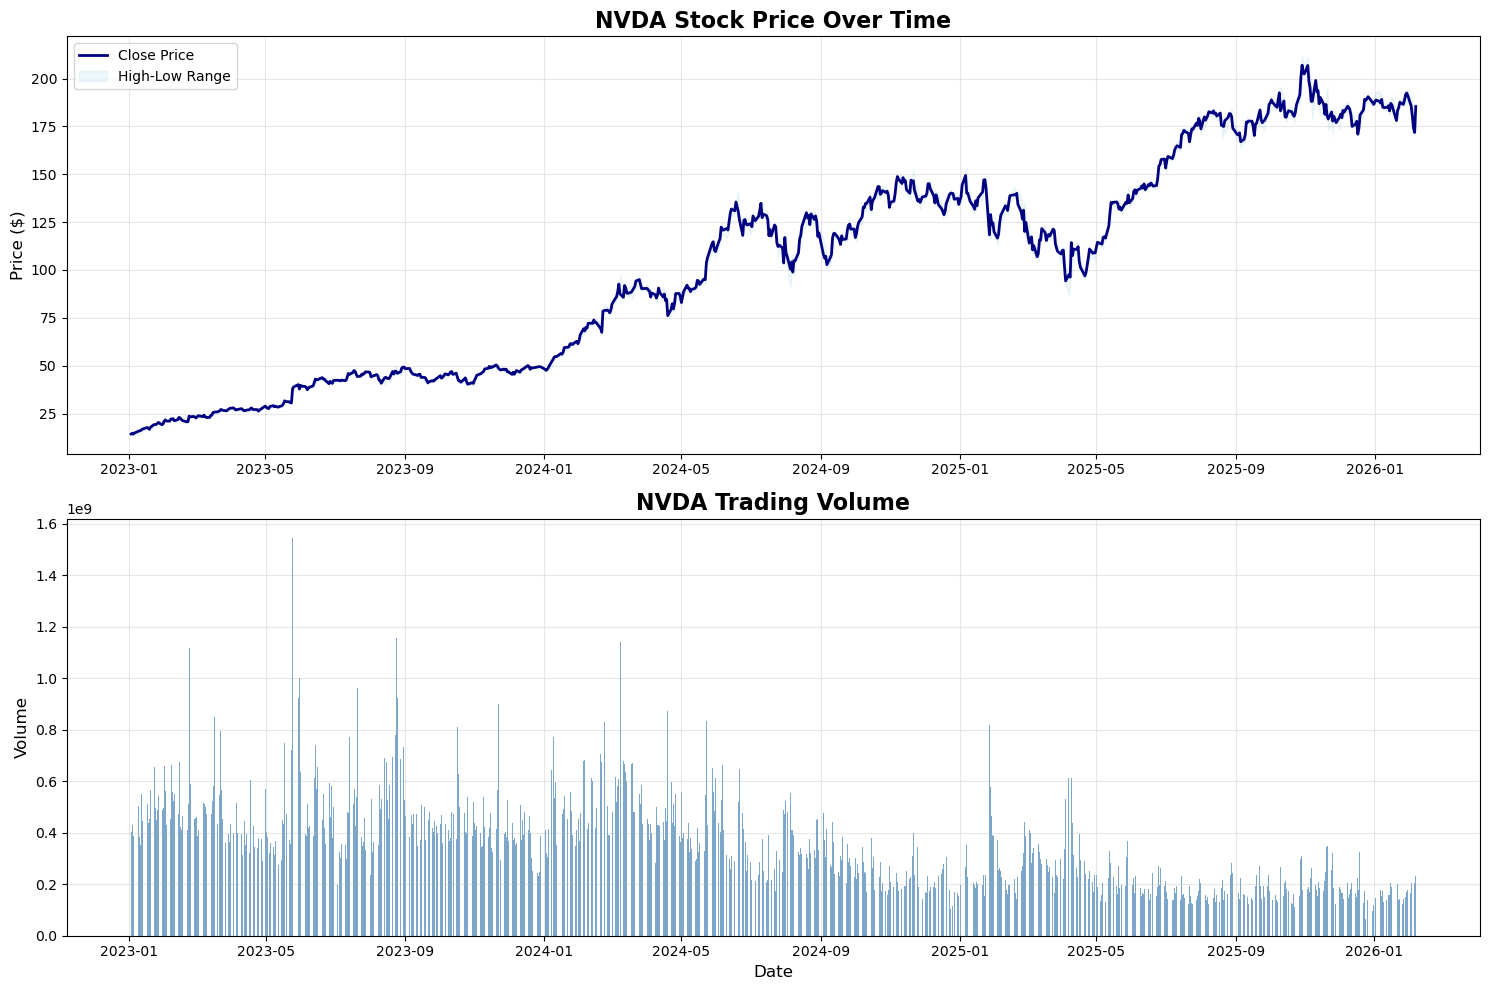


Price Range: $14.25 - $207.03
Average Daily Volume: 351,268,303
Total Return: 1196.51%


In [4]:
# Statistical summary
print(stock_data.describe())

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Price chart
ax1.plot(stock_data.index, stock_data['Close'], linewidth=2, color='navy', label='Close Price')
ax1.fill_between(stock_data.index, stock_data['Low'], stock_data['High'], alpha=0.2, color='lightblue', label='High-Low Range')
ax1.set_title(f'{STOCK_SYMBOL} Stock Price Over Time', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Volume chart
ax2.bar(stock_data.index, stock_data['Volume'], color='steelblue', alpha=0.7)
ax2.set_title(f'{STOCK_SYMBOL} Trading Volume', fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nPrice Range: ${stock_data["Close"].min():.2f} - ${stock_data["Close"].max():.2f}')
print(f'Average Daily Volume: {stock_data["Volume"].mean():,.0f}')
print(f'Total Return: {(stock_data["Close"].iloc[-1]/stock_data["Close"].iloc[0] - 1)*100:.2f}%')

## 5. Technical Indicators Implementation

We implement several technical indicators that will be used in our trading strategies.

In [5]:
def compute_RSI(series, period=14, method="wilder"):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    if method.lower() == "wilder":
        #Wilder's smoothing method
        avg_gain = gain.rolling(window=period, min_periods=period).mean()[:period+1]
        avg_loss = loss.rolling(window=period, min_periods=period).mean()[:period+1]
        
        for i in range(period+1, len(series)):
            avg_gain.iat[i] = (avg_gain.iat[i-1] * (period-1) + gain.iat[i]) / period
            avg_loss.iat[i] = (avg_loss.iat[i-1] * (period-1) + loss.iat[i]) / period
        
        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
    else:
        #EMA-based method
        avg_gain = gain.ewm(span=period, adjust=False).mean()
        avg_loss = loss.ewm(span=period, adjust=False).mean()
        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
    
    return rsi

print('RSI function defined')

RSI function defined


## 6. Trading Strategies Implementation

We implement four different trading strategies:
1. **Moving Average (MA) Strategy**: Golden Cross / Death Cross
2. **MACD Strategy**: Moving Average Convergence Divergence
3. **RSI Strategy**: Relative Strength Index
4. **Hybrid Strategy**: Combination of MA and MACD

In [6]:
def compute_RSI(series, period=14):
    series = series.astype(float).copy()
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Wilder smoothing via EWM with alpha = 1/period (adjust=False matches Wilder)
    avg_gain = gain.ewm(alpha=1.0/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1.0/period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))

    return rsi


In [7]:
#copyfor strategies
data = stock_data.copy()

In [8]:
#Moving Average (MA)
short_window = 20
long_window = 50

data['MA_Short'] = data['Close'].rolling(window=short_window, min_periods=1).mean()
data['MA_Long'] = data['Close'].rolling(window=long_window, min_periods=1).mean()
data['MA_Signal'] = 0
data.loc[data['MA_Short'] > data['MA_Long'], 'MA_Signal'] = 1  # Buy signal
data.loc[data['MA_Short'] < data['MA_Long'], 'MA_Signal'] = -1  # Sell signal
data['MA_Position'] = data['MA_Signal'].diff()

print(f'Moving Average Strategy implemented (Windows: {short_window}, {long_window})')
print(f'Buy signals: {(data["MA_Position"] == 1).sum()}')
print(f'Sell signals: {(data["MA_Position"] == -1).sum()}')

# MACD
fast_period = 12
slow_period = 26
signal_period = 9

data['EMA_Fast'] = data['Close'].ewm(span=fast_period, adjust=False).mean()
data['EMA_Slow'] = data['Close'].ewm(span=slow_period, adjust=False).mean()
data['MACD'] = data['EMA_Fast'] - data['EMA_Slow']
data['MACD_Signal'] = data['MACD'].ewm(span=signal_period, adjust=False).mean()
data['MACD_Hist'] = data['MACD'] - data['MACD_Signal']
data['MACD_Position'] = 0
data.loc[data['MACD'] > data['MACD_Signal'], 'MACD_Position'] = 1
data.loc[data['MACD'] < data['MACD_Signal'], 'MACD_Position'] = -1

print(f'MACD Strategy implemented (Periods: {fast_period}/{slow_period}/{signal_period})')
print(f'Buy signals: {(data["MACD_Position"].diff() == 2).sum()}')
print(f'Sell signals: {(data["MACD_Position"].diff() == -2).sum()}')

#rsi
rsi_period = 14
rsi_oversold = 30
rsi_overbought = 70

data['RSI'] = compute_RSI(data['Close'], period=rsi_period)
print(f"Total null values in rsi: {data['RSI'].isna().sum()}")


data['RSI_Position'] = 0
data.loc[data['RSI'] < rsi_oversold, 'RSI_Position'] = 1
data.loc[data['RSI'] > rsi_overbought, 'RSI_Position'] = -1

print(f'\nRSI Strategy implemented (Period: {rsi_period}, Levels: {rsi_oversold}/{rsi_overbought})')
print(f'Buy signals: {(data["RSI_Position"] == 1).sum()}')
print(f'Sell signals: {(data["RSI_Position"] == -1).sum()}')


#Hybrid
data['Hybrid_Position'] = 0
data.loc[
    (data['MA_Signal'] == 1) & (data['MACD_Position'] == 1),
    'Hybrid_Position'
] = 1
data.loc[
    (data['MA_Signal'] == -1) | (data['MACD_Position'] == -1),
    'Hybrid_Position'
] = -1

#Hybrid (MA + MACD)
#buy when both MA and MACD agree on bullish signal; sell when either indicates bearish
data['Hybrid_Position'] = 0
data.loc[(data['MA_Signal'] == 1) & (data['MACD_Position'] == 1), 'Hybrid_Position'] = 1
data.loc[(data['MA_Signal'] == -1) | (data['MACD_Position'] == -1), 'Hybrid_Position'] = -1

print(f'\nHybrid Strategy implemented (MA + MACD)')
print(f'Buy signals: {(data["Hybrid_Position"].diff() == 2).sum()}')
print(f'Sell signals: {(data["Hybrid_Position"].diff() == -2).sum()}')

Moving Average Strategy implemented (Windows: 20, 50)
Buy signals: 1
Sell signals: 0
MACD Strategy implemented (Periods: 12/26/9)
Buy signals: 29
Sell signals: 30
Total null values in rsi: 2

RSI Strategy implemented (Period: 14, Levels: 30/70)
Buy signals: 1
Sell signals: 146

Hybrid Strategy implemented (MA + MACD)
Buy signals: 20
Sell signals: 21


## 7. Visualize Trading Signals

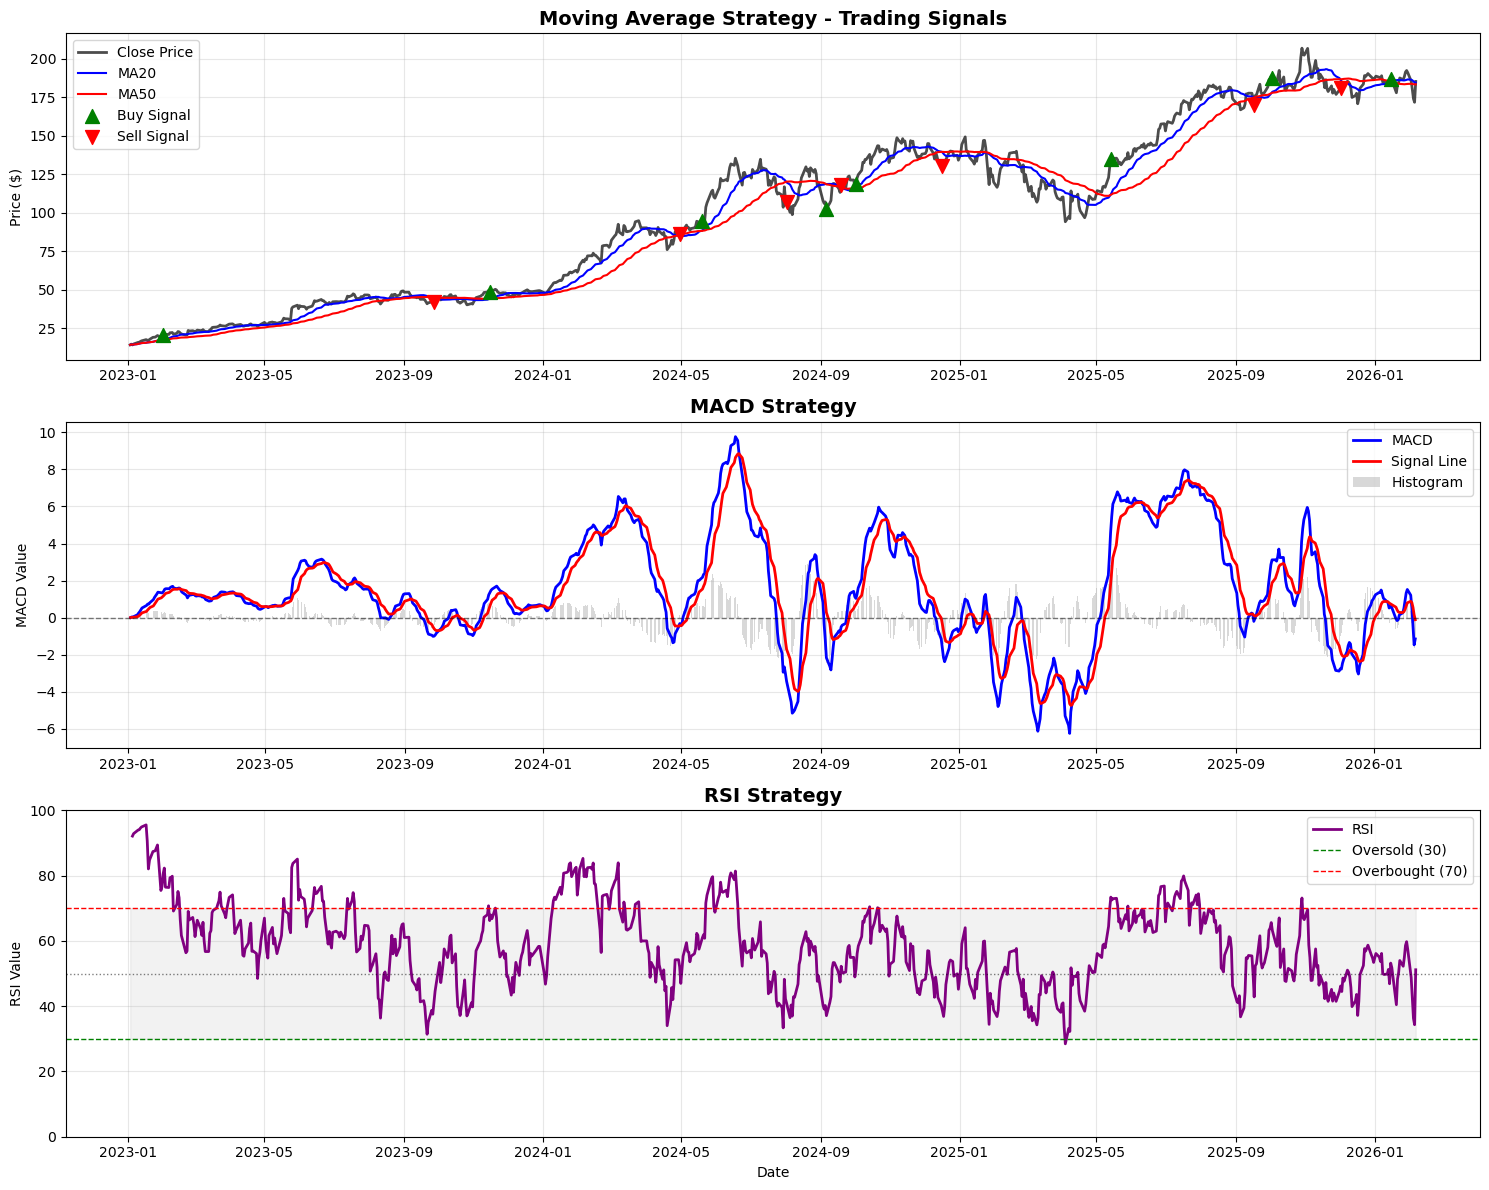

In [9]:
# Visualize Moving Average strategy
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# MA Strategy
ax1.plot(data.index, data['Close'], label='Close Price', linewidth=2, color='black', alpha=0.7)
ax1.plot(data.index, data['MA_Short'], label=f'MA{short_window}', linewidth=1.5, color='blue')
ax1.plot(data.index, data['MA_Long'], label=f'MA{long_window}', linewidth=1.5, color='red')
buy_signals_ma = data[data['MA_Position'] > 0]
sell_signals_ma = data[data['MA_Position'] < 0]
ax1.scatter(buy_signals_ma.index, buy_signals_ma['Close'], marker='^', color='green', s=100, label='Buy Signal', zorder=5)
ax1.scatter(sell_signals_ma.index, sell_signals_ma['Close'], marker='v', color='red', s=100, label='Sell Signal', zorder=5)
ax1.set_title('Moving Average Strategy - Trading Signals', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MACD Strategy
ax2.plot(data.index, data['MACD'], label='MACD', linewidth=2, color='blue')
ax2.plot(data.index, data['MACD_Signal'], label='Signal Line', linewidth=2, color='red')
ax2.bar(data.index, data['MACD_Hist'], label='Histogram', color='gray', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('MACD Strategy', fontsize=14, fontweight='bold')
ax2.set_ylabel('MACD Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

# RSI Strategy
ax3.plot(data.index, data['RSI'], label='RSI', linewidth=2, color='purple')
ax3.axhline(y=rsi_oversold, color='green', linestyle='--', linewidth=1, label=f'Oversold ({rsi_oversold})')
ax3.axhline(y=rsi_overbought, color='red', linestyle='--', linewidth=1, label=f'Overbought ({rsi_overbought})')
ax3.axhline(y=50, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax3.fill_between(data.index, rsi_oversold, rsi_overbought, alpha=0.1, color='gray')
ax3.set_title('RSI Strategy', fontsize=14, fontweight='bold')
ax3.set_ylabel('RSI Value')
ax3.set_xlabel('Date')
ax3.set_ylim(0, 100)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Trading Simulator Class

This class handles the mock trading environment with realistic commission and slippage.

In [10]:
class TradingSimulator:
    def __init__(self, initial_capital=100000, commission=0.001, slippage=0.0005, allow_fractional=True):
        self.initial_capital = initial_capital
        self.commission = commission
        self.slippage = slippage
        self.allow_fractional = allow_fractional
        self.reset()

    
    def reset(self):
        self.cash = self.initial_capital
        self.shares = 0.0
        self.trades = []
        self.portfolio_table = []
    
    def _exec_price(self, price, side):
        if side == "BUY":
            return price * (1 + self.slippage)
        else:
            return price * (1 - self.slippage)
    
    def _commission_cost(self, value):
        return value * self.commission

    
    def execute_trade(self, date, price, buy=False, sell=False):
        if buy and self.cash > 0:
            # Buy with all available cash
            exec_price = self._exec_price(price, "BUY")
            shares = self.cash / (exec_price * (1 + self.commission))
            
            if not self.allow_fractional:
                shares = int(shares)
            
            if shares > 0:
                cost = shares * exec_price
                fee = self._commission_cost(cost)
                self.cash -= (cost + fee)
                self.shares += shares
                self.trades.append({
                    "Date": date,
                    "Type": "BUY",
                    "Price": exec_price,
                    "Shares": shares,
                    "Cost": cost,
                    "Commission": fee
                })
        
        elif sell and self.shares > 0:
            # Sell all shares
            exec_price = self._exec_price(price, "SELL")
            value = self.shares * exec_price
            fee = self._commission_cost(value)
            self.cash += (value - fee)
            self.trades.append({
                "Date": date,
                "Type": "SELL",
                "Price": exec_price,
                "Shares": self.shares,
                "Value": value,
                "Commission": fee
            })
            self.shares = 0.0
    
    def run(self, df, price_col="Close", buy_col="BuyEvent", sell_col="SellEvent"):
        self.reset()
        
        for date, row in df.iterrows():
            # Execute trades if signals present
            self.execute_trade(date, row[price_col], row.get(buy_col, False), row.get(sell_col, False))
            
            # Record portfolio state
            total_value = self.cash + self.shares * row[price_col]
            self.portfolio_table.append({
                "Date": date,
                "Cash": self.cash,
                "Shares": self.shares,
                "Price": row[price_col],
                "Total_Value": total_value
            })

        if self.shares > 0:
            last_price = df.iloc[-1][price_col]
            last_date = df.index[-1]
            self.execute_trade(last_date, last_price, buy=False, sell=True)
            # Update final portfolio value
            self.portfolio_table[-1]['Cash'] = self.cash
            self.portfolio_table[-1]['Shares'] = 0.0
            self.portfolio_table[-1]['Total_Value'] = self.cash
        
        return (
            pd.DataFrame(self.portfolio_table).set_index("Date"),
            pd.DataFrame(self.trades)
        )
    
    def run_backtest(self, data, signal_column, price_col='Close'):

        df = data.copy()
        signal = df[signal_column].fillna(0).astype(int)
        prev_signal = signal.shift(1).fillna(0).astype(int)
        df['BuyEvent'] = (prev_signal <= 0) & (signal == 1)
        df['SellEvent'] = (prev_signal == 1) & (signal <= 0)
        
        return self.run(df, price_col=price_col, buy_col='BuyEvent', sell_col='SellEvent')

## 9. Run Backtests for All Strategies

In [11]:
strategies = {
    'Moving Average': 'MA_Signal',
    'MACD': 'MACD_Position',
    'RSI': 'RSI_Position',
    'Hybrid': 'Hybrid_Position'
}

results = {}
trades_log = {}

print('Running backtests')

for strategy_name, signal_col in strategies.items():
    print(strategy_name)

    simulator = TradingSimulator(
        initial_capital=INITIAL_CAPITAL,
        commission=COMMISSION_RATE,
        slippage=SLIPPAGE_RATE
    )

    portfolio_df, trades_df = simulator.run_backtest(data, signal_column=signal_col)

    results[strategy_name] = portfolio_df
    trades_log[strategy_name] = trades_df

    final_value = portfolio_df['Total_Value'].iloc[-1]
    total_return = (final_value / INITIAL_CAPITAL - 1) * 100

    print(len(trades_df))
    print(final_value)
    print(total_return)


Running backtests
Moving Average
16
601204.3614907815
501.20436149078154
MACD
60
327429.07464155427
227.42907464155428
RSI
2
103220.77688516118
3.2207768851611807
Hybrid
42
278047.4825586404
178.0474825586404


In [12]:
print('Sample Portfolio Data (Moving Average Strategy):')
print(results['Moving Average'].head(10))

print('\nSample Trades (Moving Average Strategy):')
if len(trades_log['Moving Average']) > 0:
    print(trades_log['Moving Average'].head(10))
else:
    print('No trades executed for this strategy')

Sample Portfolio Data (Moving Average Strategy):
                Cash  Shares      Price  Total_Value
Date                                                
2023-01-03  100000.0     0.0  14.300681     100000.0
2023-01-04  100000.0     0.0  14.734250     100000.0
2023-01-05  100000.0     0.0  14.250735     100000.0
2023-01-06  100000.0     0.0  14.844142     100000.0
2023-01-09  100000.0     0.0  15.612371     100000.0
2023-01-10  100000.0     0.0  15.893088     100000.0
2023-01-11  100000.0     0.0  15.984998     100000.0
2023-01-12  100000.0     0.0  16.494484     100000.0
2023-01-13  100000.0     0.0  16.882099     100000.0
2023-01-17  100000.0     0.0  17.684298     100000.0

Sample Trades (Moving Average Strategy):
        Date  Type       Price       Shares           Cost  Commission  \
0 2023-02-01   BUY   20.932517  4772.483826   99900.099900   99.900100   
1 2023-09-27  SELL   42.419400  4772.483826            NaN  202.445901   
2 2023-11-15   BUY   48.880912  4133.339715  202041

## 10. Performance Metrics Calculation

In [13]:
def calculate_performance_metrics(portfolio_df, trades_df, initial_capital, risk_free_rate=0.02):
    final_value = portfolio_df['Total_Value'].iloc[-1]
    total_return = (final_value / initial_capital - 1) * 100
    
    #Calculate returns
    returns = portfolio_df['Total_Value'].pct_change().dropna()
    #Annualized return
    days = (portfolio_df.index[-1] - portfolio_df.index[0]).days
    years = days / 365.25 if days > 0 else 0
    annualized_return = ((final_value / initial_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    
    #Volatility
    volatility = returns.std() * np.sqrt(252) * 100  # 252 trading days
    
    #Sharpe Ratio
    excess_return = annualized_return/100 - risk_free_rate
    sharpe_ratio = excess_return / (volatility/100) if volatility > 0 else 0
    
    #Max Drawdown
    cumulative = portfolio_df['Total_Value']
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max * 100
    max_drawdown = drawdown.min()
    
    #Trade statistics
    num_trades = len(trades_df)
    
    #if we have paired trades
    if num_trades >= 2:
        # Pair buy and sell trades
        buys = trades_df[trades_df['Type'] == 'BUY']
        sells = trades_df[trades_df['Type'] == 'SELL']
        
        wins = 0
        total_trades_paired = min(len(buys), len(sells))
        
        for i in range(total_trades_paired):
            buy_price = buys.iloc[i]['Price']
            sell_price = sells.iloc[i]['Price']
            if sell_price > buy_price:
                wins += 1
        
        win_rate = (wins / total_trades_paired * 100) if total_trades_paired > 0 else 0
    else:
        win_rate = 0
    
    return {
        'Final Value ($)': final_value,
        'Total Return (%)': total_return,
        'Annualized Return (%)': annualized_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown,
        'Number of Trades': num_trades,
        'Win Rate (%)': win_rate
    }

# Calculate metrics for all strategies
metrics_dict = {}
for strategy_name in strategies.keys():
    metrics = calculate_performance_metrics(
        results[strategy_name], 
        trades_log[strategy_name], 
        INITIAL_CAPITAL,
        RISK_FREE_RATE
    )
    metrics_dict[strategy_name] = metrics

# Also calculate Buy & Hold metrics
buy_hold_value = []
first_price = data['Close'].iloc[0]
shares_bought = INITIAL_CAPITAL / first_price
for price in data['Close']:
    buy_hold_value.append(shares_bought * price)

buy_hold_df = pd.DataFrame({
    'Total_Value': buy_hold_value
}, index=data.index)

days = (data.index[-1] - data.index[0]).days
years = days / 365.25


buy_hold_metrics = {
    'Final Value ($)': buy_hold_df['Total_Value'].iloc[-1],
    'Total Return (%)': (buy_hold_df['Total_Value'].iloc[-1] / INITIAL_CAPITAL - 1) * 100,
    'Annualized Return (%)': ((buy_hold_df['Total_Value'].iloc[-1] / INITIAL_CAPITAL) ** (1/years) - 1) * 100,
    'Volatility (%)': data['Close'].pct_change().std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (((buy_hold_df['Total_Value'].iloc[-1] / INITIAL_CAPITAL) ** (1/years) - 1) - RISK_FREE_RATE) / (data['Close'].pct_change().std() * np.sqrt(252)),
    'Max Drawdown (%)': ((buy_hold_df['Total_Value'] - buy_hold_df['Total_Value'].cummax()) / buy_hold_df['Total_Value'].cummax() * 100).min(),
    'Number of Trades': 1,  # Just buy and hold
    'Win Rate (%)': 100 if buy_hold_df['Total_Value'].iloc[-1] > INITIAL_CAPITAL else 0
}
metrics_dict['Buy & Hold'] = buy_hold_metrics

# Create metrics DataFrame
metrics_df = pd.DataFrame(metrics_dict).T

print('performance metrics')
print(metrics_df.to_string())

performance metrics
                Final Value ($)  Total Return (%)  Annualized Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Number of Trades  Win Rate (%)
Moving Average     6.012044e+05        501.204361              78.567899       38.909546      1.967844        -23.491660              16.0     75.000000
MACD               3.274291e+05        227.429075              46.724079       34.824526      1.284270        -42.896631              60.0     43.333333
RSI                1.032208e+05          3.220777               1.029906        1.925663     -0.503772         -0.149825               2.0    100.000000
Hybrid             2.780475e+05        178.047483              39.172239       26.351328      1.410640        -17.726193              42.0     47.619048
Buy & Hold         1.296512e+06       1196.511699             128.919520       49.883644      2.544311        -36.881027               1.0    100.000000


## 11. Performance Visualization

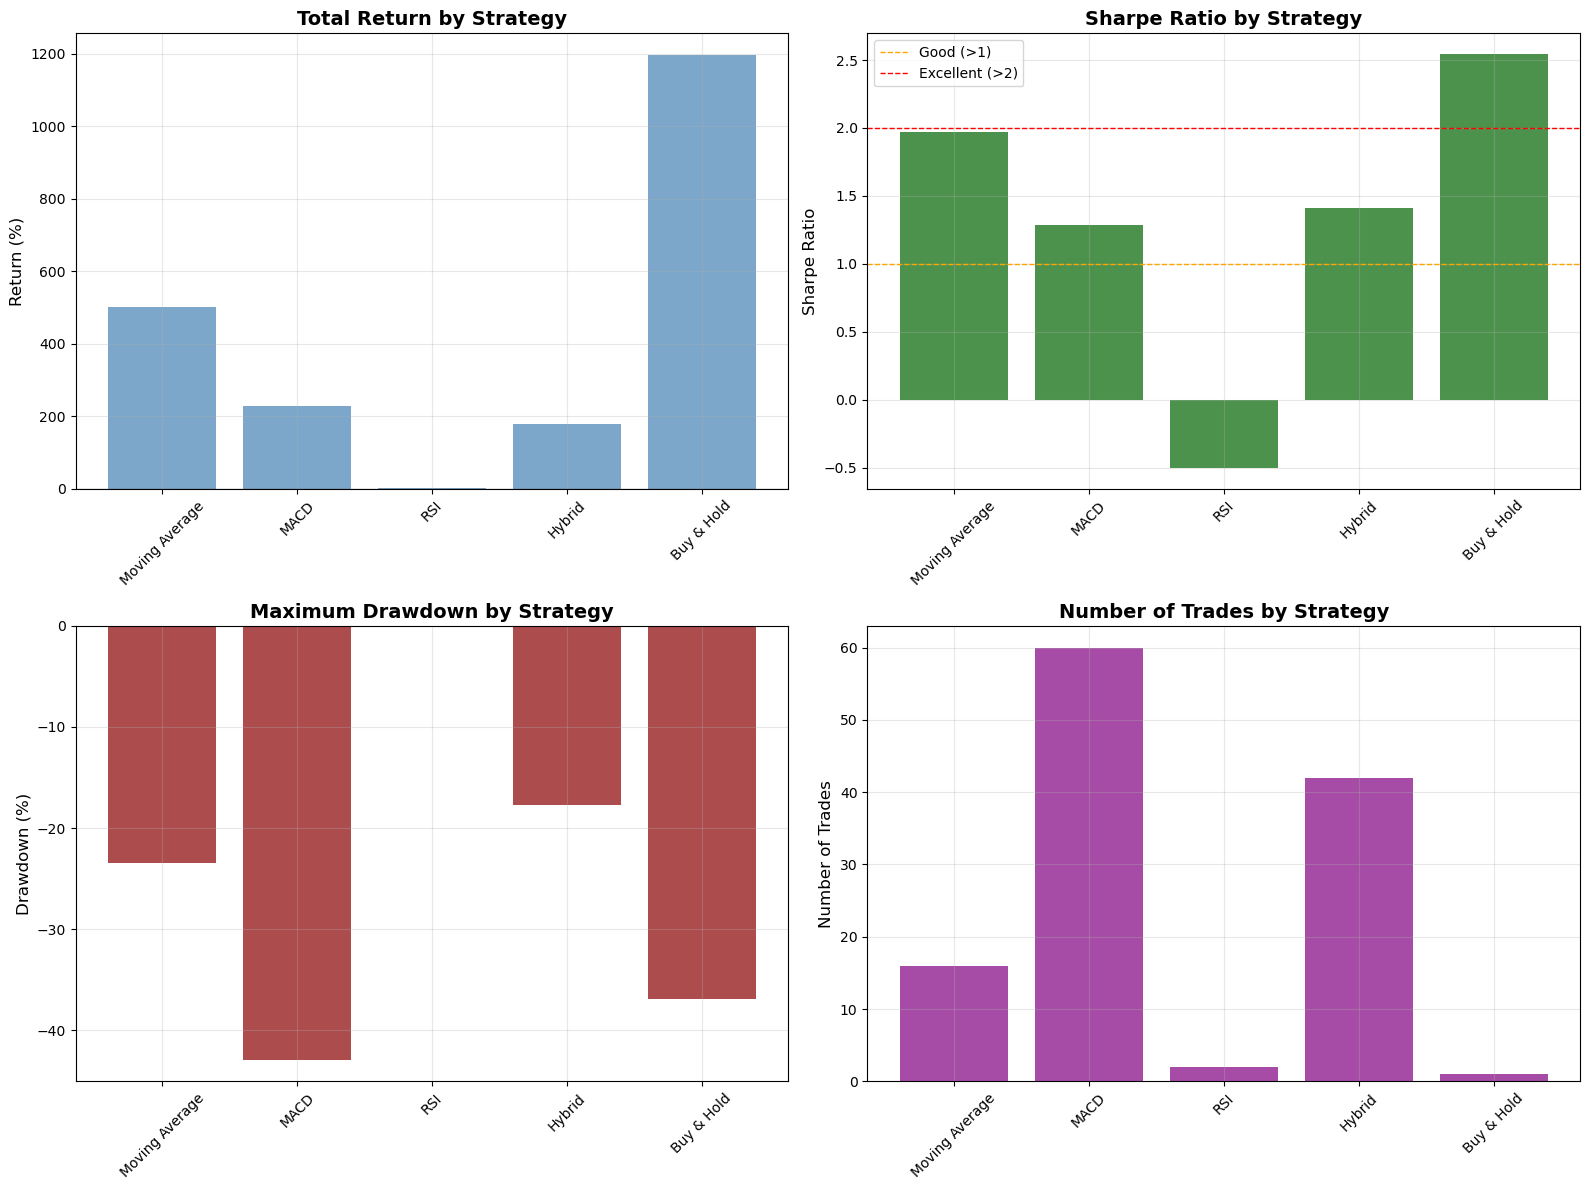

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total Return
axes[0, 0].bar(metrics_df.index, metrics_df['Total Return (%)'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Total Return by Strategy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Return (%)', fontsize=12)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Sharpe Ratio
axes[0, 1].bar(metrics_df.index, metrics_df['Sharpe Ratio'], color='darkgreen', alpha=0.7)
axes[0, 1].set_title('Sharpe Ratio by Strategy', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sharpe Ratio', fontsize=12)
axes[0, 1].axhline(y=1, color='orange', linestyle='--', linewidth=1, label='Good (>1)')
axes[0, 1].axhline(y=2, color='red', linestyle='--', linewidth=1, label='Excellent (>2)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Max Drawdown
axes[1, 0].bar(metrics_df.index, metrics_df['Max Drawdown (%)'], color='darkred', alpha=0.7)
axes[1, 0].set_title('Maximum Drawdown by Strategy', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Drawdown (%)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Number of Trades
axes[1, 1].bar(metrics_df.index, metrics_df['Number of Trades'], color='purple', alpha=0.7)
axes[1, 1].set_title('Number of Trades by Strategy', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Trades', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Portfolio Value Comparison

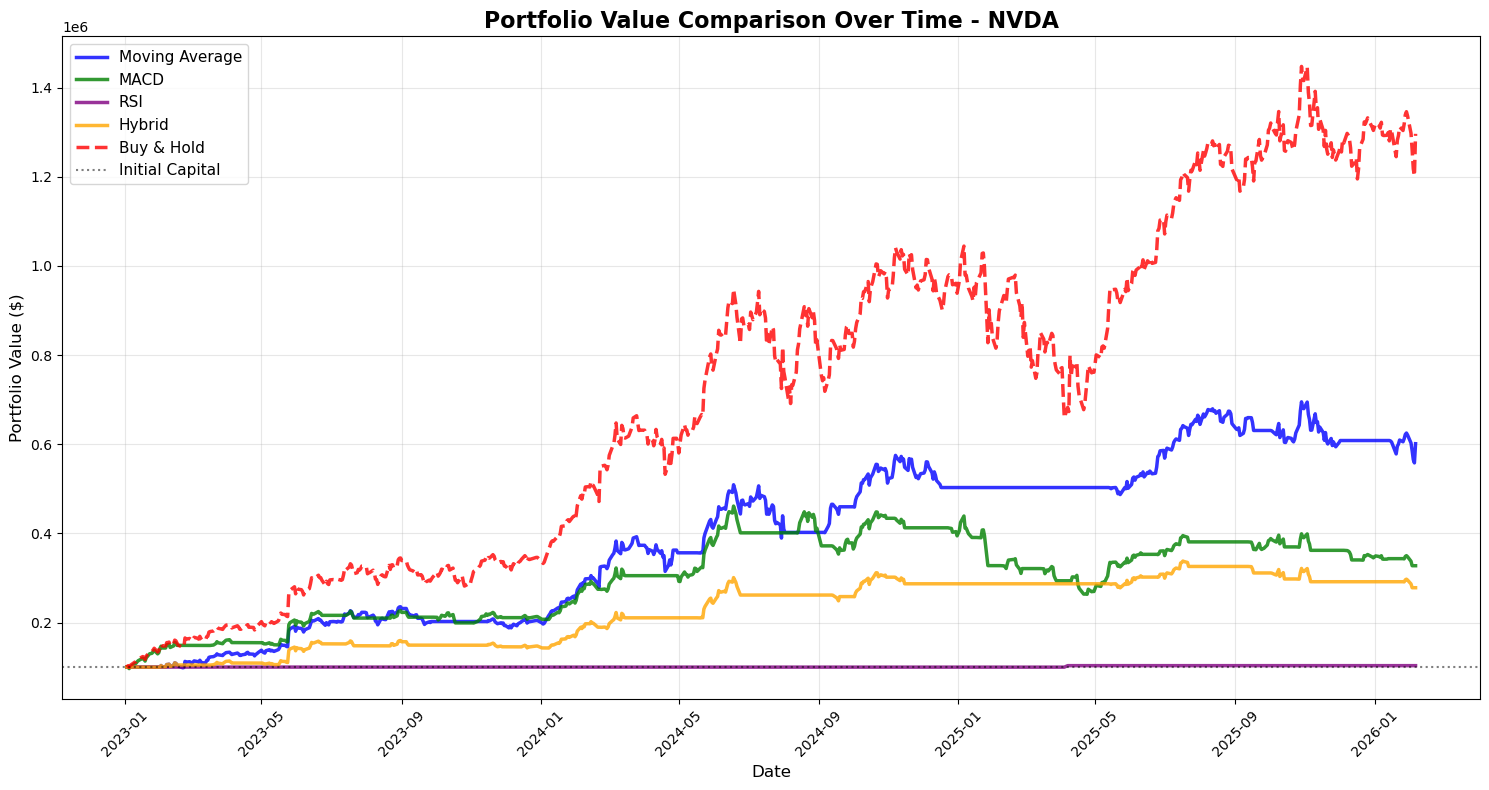

In [15]:
fig, ax = plt.subplots(figsize=(15, 8))

# Plot each strategy
colors = ['blue', 'green', 'purple', 'orange', 'red']
linestyles = ['-', '-', '-', '-', '--']

for idx, (strategy_name, portfolio_df) in enumerate(results.items()):
    ax.plot(portfolio_df.index, portfolio_df['Total_Value'], 
            label=strategy_name, linewidth=2.5, alpha=0.8,
            color=colors[idx], linestyle=linestyles[idx])

# Add Buy & Hold
ax.plot(data.index, buy_hold_value, 
        label='Buy & Hold', linewidth=2.5, linestyle='--', 
        alpha=0.8, color=colors[4])

# Add initial capital line
ax.axhline(y=INITIAL_CAPITAL, color='black', linestyle=':', 
           label='Initial Capital', alpha=0.5, linewidth=1.5)

# Formatting
ax.set_title(f'Portfolio Value Comparison Over Time - {STOCK_SYMBOL}', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Additional Analysis - Trade Statistics

In [16]:
for strategy_name, trades_df in trades_log.items():
    print(strategy_name)

    print(len(trades_df))

    buys = trades_df[trades_df['Type'] == 'BUY']
    sells = trades_df[trades_df['Type'] == 'SELL']

    print(len(buys))
    print(len(sells))

    if 'Commission' in trades_df.columns:
        print(trades_df['Commission'].sum())


Moving Average
16
8
8
7026.961245725759
MACD
60
30
30
17353.542618005602
RSI
2
1
1
203.22420088624727
Hybrid
42
21
21
8780.71831192155
